In [4]:
import HeST as hest
import HeST.Amherst_split_cpd as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection

import astropy.stats as astat

In [5]:

detector = examp.Amherst_split_cpd 


QP_conditions= detector.get_surface_conditions()
nCPDs = detector.get_nCPDs()
for i in range(nCPDs):
    QP_conditions.append( (detector.get_CPD(i)).get_surface_condition() )

QP_conditions.append( detector.liquid_surface )

0.3831846824184455 [0.17540271282238745, 0.20778196959605802] 2 2


Text(0, 0.5, 'Counts/bin')

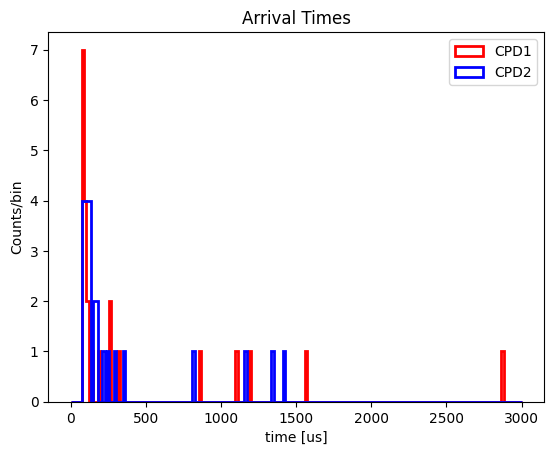

In [6]:
pos = [0., 0., 1.5]
useMap = False
evap = hest.GetEvaporationSignal( detector, 10000, *pos, useMap=useMap)
print( evap.area_eV, evap.chArea_eV, evap.coincidence, len(evap.arrivalTimes_us))

plt.hist(evap.arrivalTimes_us[0], bins=200, range=[0, 3000], histtype='step', color='r', lw=2, label = 'CPD1')
plt.hist(evap.arrivalTimes_us[1], bins=200, range=[0, 3000], histtype='step', color='b', lw=2, label = 'CPD2')
plt.legend()
plt.title('Arrival Times')
plt.xlabel('time [us]')
plt.ylabel('Counts/bin')

In [7]:
import HeST.Detection as detection
import os
import numpy as np
#The detector geometry is defined from the point of view of particle paths.
# We essentially want to define various "surface conditions" where the particle paths are obstructed
# These functions also carry a "boundary_type", so that we can keep track if the particle is obstructed by
# a CPD, or a wall, and how it may reflect off of a given wall.

def sensor1_conditions(x, y, z):
    boundary_type = "CPD0"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) & (x>0)& (z < height)| (x*x + y*y >= radius*radius) , boundary_type

def sensor2_conditions(x, y, z):
    boundary_type = "CPD1"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) &  (x<0)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type





baseline_noise = [0., 0.]
phonon_conversion = 0.25
cpd1 = detection.VCPD(sensor1_conditions, baseline_noise, phonon_conversion)
cpd2 = detection.VCPD(sensor2_conditions, baseline_noise, phonon_conversion)





def wall_conditions(x, y, z):
    boundary_type = "XY"
    radius = 3. #cm
    height = 2.75 #cm
    return ((x*x + y*y < radius*radius) & (z < height) ) | (z > height), boundary_type

def bottom_conditions(x, y, z):
    boundary_type = "Z"
    bottom = 0. #cm
    return (z > bottom), boundary_type

def liquid_surface(x, y, z):
    boundary_type = "Liquid"
    height = 2.75 #cm
    return (z < height), boundary_type

def liquid_conditions(x, y, z):
    height = 2.75 #cm
    radius = 3. #cm
    bottom = 0. #cm
    return ((x*x + y*y < radius*radius) & (z < height) & (z > bottom))
   

Amherst_split_cpd = detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)

 

0.6673001546120167 [0.2918796489531521, 0.3754205056588646] 2 2
0.5009573034620705 [0.24381258515073034, 0.2571447183113401] 2 2
0.4509633179596145 [0.14660337402688217, 0.3043599439327323] 2 2
0.5791242765954157 [0.30335897020814107, 0.27576530638727464] 2 2
0.5417766712502257 [0.27708030179176113, 0.26469636945846453] 2 2
0.5412315359309988 [0.2711315703912477, 0.27009996553975113] 2 2
0.4573700476928194 [0.1589474163756506, 0.29842263131716884] 2 2
0.5821949918428835 [0.24949211620418593, 0.3327028756386976] 2 2
0.6460085337968752 [0.340103938174401, 0.3059045956224742] 2 2
0.5190680750737627 [0.2784474913442296, 0.24062058372953318] 2 2


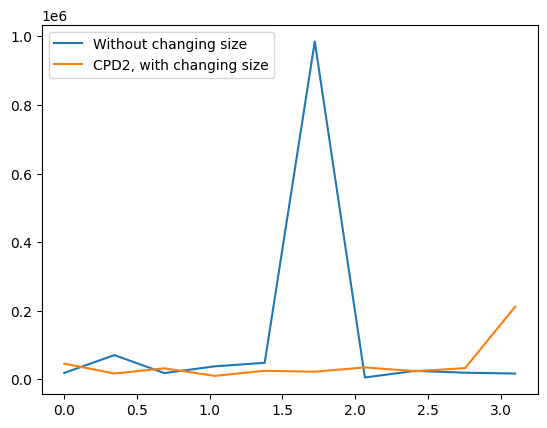

In [13]:
def sensor2_conditions(x, y, z):
    boundary_type = "CPD1"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) &  (x<0)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type

detector= detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)


cpd_2_x_bounds = np.linspace(0,-3.1, 10)
signals_cpd1 = np.empty_like(cpd_2_x_bounds)
signals_cpd2 = np.empty_like(cpd_2_x_bounds)


for ii, bound in enumerate(cpd_2_x_bounds):
    pos = [0., 0., 1.5]
    def sensor2_conditions(x, y, z):
        boundary_type = "CPD1"
        radius = 3.8
        height = 3.3
        return (x*x + y*y < radius*radius) &  (x<bound)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type
    detector = detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)

    useMap = False
    evap = hest.GetEvaporationSignal( detector, 10000, *pos, useMap=useMap)
    print( evap.area_eV, evap.chArea_eV, evap.coincidence, len(evap.arrivalTimes_us))
    signals_cpd1[ii] = np.sum(evap.arrivalTimes_us[0])
    signals_cpd2[ii] = np.sum(evap.arrivalTimes_us[1])

plt.plot(cpd_2_x_bounds, signals_cpd1, label = 'Without changing size')
plt.plot(cpd_2_x_bounds, signals_cpd2, label = 'CPD2, with changing size')
plt.legend()
